# Avances y próximos pasos — tras la sesión del 9 de julio

La sesión reorientó el trabajo hacia un paper concreto y cercano. La pieza
central es un ejemplo de **separación**: una familia mínima donde una
estrategia dinámica con pruebas aumentadas supera de forma cerrada al mejor
esquema estático sin aumentar. Alrededor quedan cuatro frentes: un algoritmo
eficiente sobre los regímenes tratables, el modelo realista de pruebas, la
verificación de la fibra, y el encuadre de publicación.

Este cuaderno regenera cada número; nada está escrito a mano.

In [1]:
import math
import itertools
import numpy as np
import matplotlib.pyplot as plt

AZUL, GRIS, AMBAR, TINTA = '#2563eb', '#6b7280', '#d97706', '#374151'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'grid.linewidth': 0.5, 'font.size': 10})

# --- el ejemplo de separación, en dos funciones ---
def util_estatico(B, q):
    '''Óptimo estático (individual) sobre u: B*q.'''
    return B * q

def util_dinamico(B, G, q):
    '''Cota inferior del dinámico aumentado sobre u: 1-(1-q)^(kG),
    con kG=(B-log2 G)*G. Devuelve (valor, kG) o (None, None) si B<1+log2 G.'''
    logG = math.log2(G)
    if abs(logG - round(logG)) > 1e-9:
        raise ValueError('G debe ser potencia de 2')
    logG = round(logG)
    k = B - logG
    if k < 1:
        return None, None
    kG = k * G
    return 1.0 - (1.0 - q) ** kG, kG

print('funciones listas')

funciones listas


## 1. El ejemplo de separación

**El montaje.** Población infinita y homogénea: cada persona tiene utilidad
$u$ y probabilidad $q$ de estar sana (infectada con probabilidad $1-q$).
Pruebas de grupo de tamaño $G$; presupuesto $B = k + \log_2 G$; y $q < 1/2$
(prevalencia alta). Se acredita $u$ a quien queda *probado sano*, es decir, en
un pool cuyo conteo de infectados es cero.

La pregunta que ancla el paper: ¿cuándo un esquema **dinámico con conteo**
supera al mejor esquema **estático sin conteo**? Este ejemplo lo exhibe en
forma cerrada.

**Óptimo estático.** El recurso escaso es el número de pruebas, no la gente,
así que la métrica correcta es utilidad esperada por prueba. Una prueba
individual acredita $u$ con probabilidad $q$: rinde $u\,q$. Una prueba de
grupo de tamaño $g$ acredita a sus $g$ miembros solo si todos están sanos
(probabilidad $q^g$): rinde $u\,g\,q^g$. Individual domina cuando
$g\,q^{g-1}\le 1$, y para $q<1/2$, $g\ge 2$ eso se cumple siempre
($g/2^{g-1}\le 1$). El valor óptimo estático es entonces

$$U^{\text{est}} = B\,u\,q.$$

**Dinámico aumentado.** Con el presupuesto $B=k+\log_2 G$ se hacen $k$ pruebas
sobre $k$ grupos disjuntos de $G$ personas — cubren $kG$ en total —, y si un
grupo reporta al menos un sano, se aísla con una búsqueda binaria de conteo en
$\log_2 G$ pruebas. La búsqueda encuentra a un sano con certeza (invariante: un
bloque cuyo conteo de infectados es menor que su tamaño contiene al menos un
sano). El esquema acredita a lo más una persona, así que su utilidad es
exactamente

$$U^{\text{din}} = u\,\bigl(1-(1-q)^{kG}\bigr), \qquad kG=(B-\log_2 G)\,G,$$

una cota inferior del óptimo dinámico (el óptimo puede además certificar gratis
a los $G$ miembros de un grupo que salga con conteo cero).

In [2]:
# instancia ancla: prevalencia alta (q=0.1), grupos de 16, presupuesto 6
q, G, B = 0.1, 16, 6
est = util_estatico(B, q)
din, kG = util_dinamico(B, G, q)
print(f'q={q}  G={G}  B={B}  (k={B-round(math.log2(G))}, cubre kG={kG} personas)')
print(f'  estático  U/u = B*q          = {est:.3f}')
print(f'  dinámico  U/u = 1-(1-q)^kG   = {din:.3f}')
print(f'  ventaja del dinámico: {din-est:+.3f}u  ({100*(din/est-1):+.0f}%)')

q=0.1  G=16  B=6  (k=2, cubre kG=32 personas)
  estático  U/u = B*q          = 0.600
  dinámico  U/u = 1-(1-q)^kG   = 0.966
  ventaja del dinámico: +0.366u  (+61%)


**La separación, y un matiz sobre el exponente.** El dinámico supera al
estático cuando $1-(1-q)^{kG} > B\,q$. Francisco escribió la cobertura como
$kG\approx B$; la cobertura real es $kG=(B-\log_2 G)\,G\approx B\,G$, un factor
$\sim G$ mayor. El matiz importa, y en la dirección correcta: por la
desigualdad de Bernoulli, $1-(1-q)^{n}\le n\,q$, así que si la cobertura fuera
solo $B$ el dinámico **nunca** ganaría. Con la cobertura verdadera gana con
holgura. Corregir el exponente refuerza la tesis, no la debilita.

In [3]:
# Bernoulli: con exponente B el dinámico jamás ganaría (1-(1-q)^B <= B*q)
qs = np.linspace(0.02, 0.48, 25); Bs = np.arange(2, 15)
peor = max(float((1-(1-q)**b) - b*q) for q in qs for b in Bs)
print(f'max sobre la rejilla de (1-(1-q)^B) - B*q = {peor:.4f}   (<=0 => con kG~B nunca gana)')
print('con el exponente REAL kG=(B-log2 G)*G, en cambio, la separación sí ocurre (abajo)')

max sobre la rejilla de (1-(1-q)^B) - B*q = -0.0004   (<=0 => con kG~B nunca gana)
con el exponente REAL kG=(B-log2 G)*G, en cambio, la separación sí ocurre (abajo)


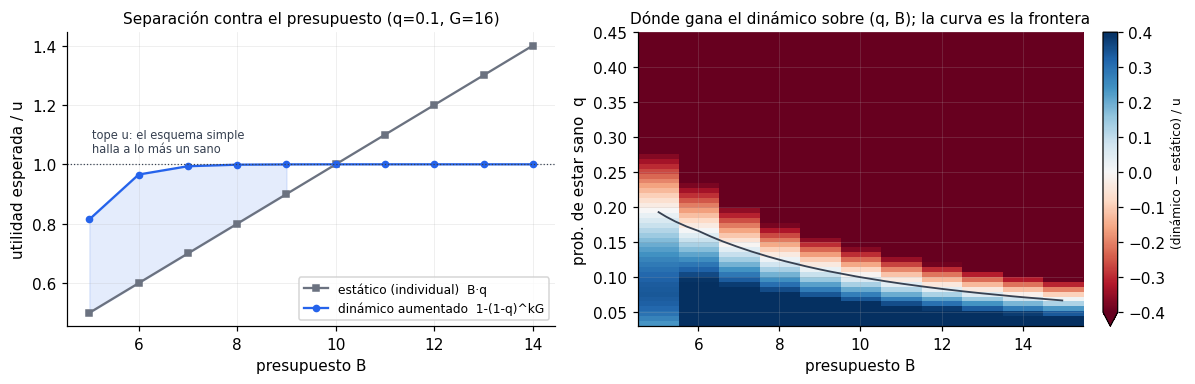

In [4]:
# figura: estático vs dinámico contra el presupuesto B (q=0.1, G=16)
q, G = 0.1, 16
Bs = list(range(1 + round(math.log2(G)), 15))
est = [util_estatico(b, q) for b in Bs]
din = [util_dinamico(b, G, q)[0] for b in Bs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

ax1.plot(Bs, est, marker='s', ms=4, color=GRIS, label='estático (individual)  B·q')
ax1.plot(Bs, din, marker='o', ms=4, color=AZUL, label='dinámico aumentado  1-(1-q)^kG')
ax1.fill_between(Bs, est, din, where=[d > e for e, d in zip(est, din)],
                 color=AZUL, alpha=0.12)
ax1.axhline(1.0, color=TINTA, ls=':', lw=0.8)
ax1.annotate('tope u: el esquema simple\nhalla a lo más un sano',
             (Bs[0], 1.0), textcoords='offset points', xytext=(2, 6),
             ha='left', va='bottom', fontsize=7.5, color=TINTA)
ax1.set_xlabel('presupuesto B'); ax1.set_ylabel('utilidad esperada / u')
ax1.set_title(f'Separación contra el presupuesto (q={q}, G={G})', fontsize=10)
ax1.legend(fontsize=8, loc='lower right')

# heatmap: región donde gana el dinámico, sobre (q, B) para G=16.
# La escala se recorta a +-0.4 (la magnitud de las victorias) para que la
# región de victoria no la aplasten las derrotas grandes de q alto; la
# frontera din=est se marca con una curva de nivel.
qs = np.linspace(0.03, 0.45, 60); Bgrid = np.arange(1 + round(math.log2(G)), 16)
adv = np.full((len(qs), len(Bgrid)), np.nan)
for i, qq in enumerate(qs):
    for j, bb in enumerate(Bgrid):
        d, _ = util_dinamico(int(bb), G, qq)
        if d is not None:
            adv[i, j] = d - util_estatico(int(bb), qq)
im = ax2.imshow(adv, origin='lower', aspect='auto', cmap='RdBu',
                vmin=-0.4, vmax=0.4,
                extent=[Bgrid[0]-.5, Bgrid[-1]+.5, qs[0], qs[-1]])
BB, QQ = np.meshgrid(Bgrid, qs)
ax2.contour(BB, QQ, adv, levels=[0.0], colors=[TINTA], linewidths=1.2)
ax2.set_xlabel('presupuesto B'); ax2.set_ylabel('prob. de estar sano  q')
ax2.set_title('Dónde gana el dinámico sobre (q, B); la curva es la frontera',
              fontsize=10)
cb = fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04, extend='min')
cb.set_label('(dinámico − estático) / u', fontsize=8)
fig.tight_layout(); plt.show()

Dos lecturas. La separación es fuerte con **prevalencia alta** ($q$
pequeño) y **presupuesto moderado**: ahí encontrar a un sano raro es caro
individualmente —el estático rinde solo $B\,q$—, pero barato con conteo, que
permite hacer búsqueda binaria de la aguja en el pajar. Y hay un cruce honesto:
como el esquema simple encuentra a lo más un sano, su utilidad topa en $u$,
mientras el estático crece lineal; para $B\gtrsim 1/q$ el estático lo rebasa.
La ventana de victoria es $1+\log_2 G \le B < 1/q$.

Refinamiento (para el apéndice): eligiendo $G$ óptimo la cobertura llega a
$kG^\ast = 2^{B-1}$, de modo que la condición canónica de separación es
$B\,q < 1-(1-q)^{2^{B-1}}$ — cobertura exponencial en el presupuesto.

**Estado:** este ejemplo, solo, ya es un resultado del paper. Francisco envía
el resultado del extremo estático; aquí queda la instancia y la verificación.

## 2. Los regímenes tratables y un algoritmo eficiente

El segundo frente: los regímenes donde la inferencia exacta —que en general es
#P-hard— se vuelve tratable, y un algoritmo (DP) eficiente sobre ellos. Dos
familias, ambas por la misma razón: el posterior factoriza cuando la estructura
de traslape es simple.

La primera es **laminar**: pools anidados (cada par de pools es disjunto o uno
contiene al otro). La segunda es **treewidth acotado** del hipergrafo de
co-aparición en pruebas. En los dos casos el conteo total se reparte en
componentes o bolsas de tamaño acotado y el posterior se computa en tiempo
polinomial, en vez de enumerar $2^n$. Empíricamente el desempeño es bueno.

El paper mandable es la terna: el ejemplo de separación de la sección 1, este
algoritmo eficiente sobre los regímenes tratables, y una columna empírica.

## 3. El modelo realista de pruebas (rama paralela)

Sin urgencia, pero es lo que vuelve el trabajo aplicable: hoy el modelo idealiza
el conteo como exacto. En una prueba real —qPCR, biomarcadores— la lectura es
ruidosa: en vez de un número, la prueba devuelve una *distribución posterior*
sobre el conteo. La pregunta es si la separación de la sección 1 sobrevive a ese
ruido. Si sobrevive, el resultado deja de ser un juguete y se vuelve una
recomendación de diseño para tamizaje. Francisco intentará compartir un artículo
de biomarcadores para calibrar el modelo de ruido.

## 4. Verificación de la fibra

En la sesión anterior surgió la duda sobre la *fibra* —los perfiles consistentes
con los conteos observados—: ¿por qué son solo cinco, y no debería valer el
perfil de todos-infectados? La respuesta, verificada abajo: la fibra son los
perfiles consistentes con lo que se *midió*, y el conteo exacto es una
restricción brutal. Todos-infectados es un estado válido a priori, pero daría
conteo 3, no 1, así que la evidencia lo descarta.

In [5]:
A = {0, 1, 2}; Bp = {2, 3, 4}   # dos pruebas que se traslapan en la persona 2
fibra_conteo, fibra_binaria = [], []
for z in itertools.product((0, 1), repeat=5):
    inf = {i for i in range(5) if z[i]}
    cA, cB = len(inf & A), len(inf & Bp)
    if cA == 1 and cB == 1:   fibra_conteo.append(z)   # aumentado: conteo exacto = 1
    if cA >= 1 and cB >= 1:   fibra_binaria.append(z)  # clásico: 'positivo' = >=1
todos = (1, 1, 1, 1, 1)
print(f'perfiles posibles: 2^5 = {2**5}')
print(f'fibra con CONTEO exacto = 1 : {len(fibra_conteo)}  ->',
      [''.join(map(str, z)) for z in fibra_conteo])
print(f'fibra con test BINARIO (>=1): {len(fibra_binaria)}')
print(f'todos-infectados en la fibra de conteo?  {todos in fibra_conteo}  '
      f'(su conteo en A = {len(set(range(5)) & A)}, no 1)')
print(f'todos-infectados en la fibra binaria?    {todos in fibra_binaria}')
print()
print('La caída de 25 a 5 perfiles ES el valor de contar: el conteo exacto')
print('descarta 20 mundos que el bit binario deja en pie.')

perfiles posibles: 2^5 = 32
fibra con CONTEO exacto = 1 : 5  -> ['00100', '01001', '01010', '10001', '10010']
fibra con test BINARIO (>=1): 25
todos-infectados en la fibra de conteo?  False  (su conteo en A = 3, no 1)
todos-infectados en la fibra binaria?    True

La caída de 25 a 5 perfiles ES el valor de contar: el conteo exacto
descarta 20 mundos que el bit binario deja en pie.


## 5. Encuadre para publicar

Del consejo de la sesión, cuatro reglas:

1. No mover dos variables a la vez. El beneficio tiene dos fuentes —ser dinámico
   y ser aumentado—; el ejemplo de la sección 1 aísla la del conteo (compara
   dinámico-aumentado contra el óptimo estático), que es lo que se quiere
   atribuir.
2. La dureza #P del posterior y la enumeración de la fibra van como trabajo
   futuro o apéndice, no en la línea principal.
3. Lo puramente dinámico (sin conteo) se refiere al trabajo previo del grupo.
4. La terna mandable es: ejemplo de separación + algoritmo eficiente en los
   regímenes tratables + evidencia empírica.

## 6. Cómo conecta con el certificado

El paper cercano y la dirección de fondo no compiten. El ejemplo de separación
mide *cuánto vale* el conteo en un caso resoluble; la línea del certificado mide
*cuánto de ese valor se puede reclamar y certificar con cómputo finito* cuando
el caso ya no es resoluble. El primero da el resultado publicable a corto plazo;
el segundo es el eje que le da coherencia a todo. La separación de la sección 1
es, de hecho, el extremo tratable del mismo objeto: donde la cota se puede
calcular exacta y la garantía es total.